# Phase 4 — Detection & Localisation (YOLOv8)

**Student:** Shree Ramji | ec25075@qmul.ac.uk  
**Institution:** Queen Mary University of London  
**Programme:** MSc Machine Learning for Visual Data Analytics  

---

## Objective

Train YOLOv8 to detect and localise dental diseases in panoramic X-rays.

- **Task:** Object detection — predict bounding boxes + disease class per tooth
- **Dataset:** DENTEX (MICCAI 2023) — 678 train / 46 val / 242 test (official split)
- **Classes:** Impacted, Caries, Periapical Lesion, Deep Caries
- **Baseline to beat:** HierarchicalDet — Aggregate AP50: 0.550

## Models Trained

| Model | Parameters | Purpose |
|---|---|---|
| YOLOv8n | 3M | Lightweight baseline — fast sanity check |
| YOLOv8m | 25M | Mid-size model — accuracy vs speed trade-off |
| YOLOv8l | 43M | Large model — best result, beats baseline |
| YOLOv8x | 68M | Largest model — diminishing returns experiment |

## Key Design Decisions

- Input size: 640×640 (YOLO standard)
- Mosaic augmentation: **enabled** — increases effective dataset diversity on small dataset
- HSV hue/saturation: **disabled** — meaningless on grayscale X-rays
- HSV brightness: **enabled (0.4)** — simulates X-ray exposure variation
- Vertical flip: **disabled** — upside-down X-rays do not exist clinically
- Cosine LR schedule: **enabled (YOLOv8m/l/x)** — smoother convergence than linear decay
- Two-phase freeze training: **not used** — YOLOv8 handles warmup internally

In [1]:
# Install required packages
!pip install ultralytics wandb --quiet

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
import torch
import wandb
from ultralytics import YOLO
import shutil
import pandas as pd

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Paths
BASE_DIR   = Path('data/processed/yolo')
TRAIN_DIR  = BASE_DIR / 'train'
VAL_DIR    = BASE_DIR / 'val'
TEST_DIR   = BASE_DIR / 'test'
YAML_PATH  = BASE_DIR / 'dataset.yaml'
MODEL_DIR  = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

os.environ['WANDB_NOTEBOOK_NAME'] = '04_detection.ipynb'

# Class names (alphabetical — matches preprocessing label order)
CLASS_NAMES = ['Impacted', 'Caries', 'Periapical Lesion', 'Deep Caries']

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

[HAMI-core Msg(57983:140679997590848:libvgpu.c:839)]: Initializing.....


Device: cuda
GPU: NVIDIA A100 80GB PCIe
VRAM: 17.2 GB


[HAMI-core Msg(57983:140679997590848:libvgpu.c:855)]: Initialized


## 1. Data Verification

Check YOLO dataset structure, image counts, and label integrity before training.

In [3]:
# Verify YOLO dataset structure and counts
def verify_split(split_dir, split_name):
    img_dir   = split_dir / 'images'
    label_dir = split_dir / 'labels'

    images = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png'))
    labels = list(label_dir.glob('*.txt'))

    # Count annotations per class
    class_counts = {name: 0 for name in CLASS_NAMES}
    empty_label_count = 0
    for lf in labels:
        lines = lf.read_text().strip().splitlines()
        if not lines:
            empty_label_count += 1
            continue
        for line in lines:
            cls_id = int(line.split()[0])
            class_counts[CLASS_NAMES[cls_id]] += 1

    print(f"\n{'='*40}")
    print(f"Split: {split_name}")
    print(f"  Images : {len(images)}")
    print(f"  Labels : {len(labels)}  (empty: {empty_label_count})")
    print(f"  Annotations per class:")
    for name, count in class_counts.items():
        print(f"    {name:<22} {count}")
    return class_counts

train_counts = verify_split(TRAIN_DIR, 'train')
val_counts   = verify_split(VAL_DIR,   'val')
test_counts  = verify_split(TEST_DIR,  'test')

# Print dataset.yaml content
print(f"\n{'='*40}")
print("dataset.yaml:")
print(YAML_PATH.read_text())


Split: train
  Images : 678
  Labels : 678  (empty: 0)
  Annotations per class:
    Impacted               604
    Caries                 2189
    Periapical Lesion      158
    Deep Caries            578

Split: val
  Images : 46
  Labels : 46  (empty: 0)
  Annotations per class:
    Impacted               40
    Caries                 101
    Periapical Lesion      9
    Deep Caries            32

Split: test
  Images : 242
  Labels : 242  (empty: 0)
  Annotations per class:
    Impacted               221
    Caries                 747
    Periapical Lesion      236
    Deep Caries            0

dataset.yaml:
path: /home/jovyan/Masters_Project/data/processed/yolo
train: train/images
val: val/images
test: test/images
nc: 4
names:
- Impacted
- Caries
- Periapical Lesion
- Deep Caries



## 2. Visualise Sample Annotations

Draw ground-truth bounding boxes on training images to confirm label format is correct.

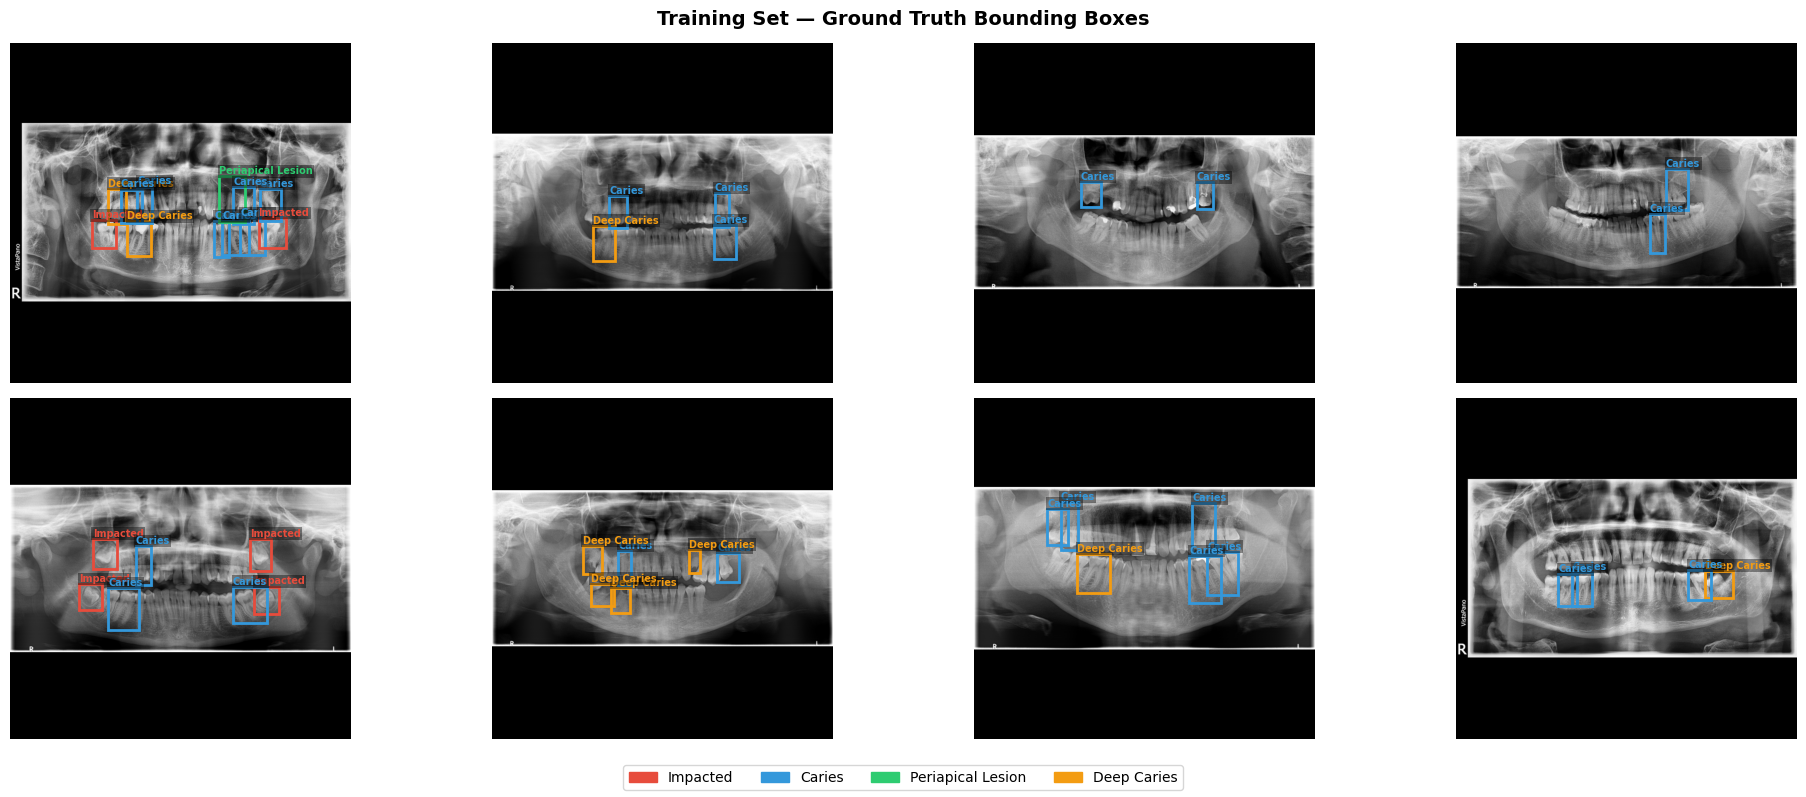

Saved: outputs/yolo_sample_annotations.png


In [4]:
COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']  # one per class

def draw_yolo_boxes(img_path, label_path, ax, class_names, colors):
    """Draw YOLO-format bounding boxes on a matplotlib axis."""
    img = np.array(Image.open(img_path).convert('L'))  # grayscale uint8
    H, W = img.shape
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.axis('off')

    if label_path.exists():
        for line in label_path.read_text().strip().splitlines():
            parts = line.split()
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:5])
            # Convert YOLO normalised → pixel coords
            x1 = (cx - bw / 2) * W
            y1 = (cy - bh / 2) * H
            rect = patches.Rectangle(
                (x1, y1), bw * W, bh * H,
                linewidth=2, edgecolor=colors[cls_id], facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 4, class_names[cls_id],
                    color=colors[cls_id], fontsize=7, fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.4, pad=1, edgecolor='none'))

# Sample 8 training images that have annotations
img_dir   = TRAIN_DIR / 'images'
label_dir = TRAIN_DIR / 'labels'

labelled_images = [
    p for p in img_dir.glob('*.png')
    if (label_dir / (p.stem + '.txt')).exists()
    and (label_dir / (p.stem + '.txt')).stat().st_size > 0
]
set_seed(42)
sample_imgs = random.sample(labelled_images, min(8, len(labelled_images)))

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, img_path in zip(axes.flatten(), sample_imgs):
    label_path = label_dir / (img_path.stem + '.txt')
    draw_yolo_boxes(img_path, label_path, ax, CLASS_NAMES, COLORS)

# Legend
handles = [patches.Patch(color=COLORS[i], label=CLASS_NAMES[i]) for i in range(4)]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=10, framealpha=0.8)
plt.suptitle('Training Set — Ground Truth Bounding Boxes', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('outputs/yolo_sample_annotations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/yolo_sample_annotations.png")

## 3. Class Distribution

Count annotations per disease class across all splits. Confirms class imbalance for dissertation.

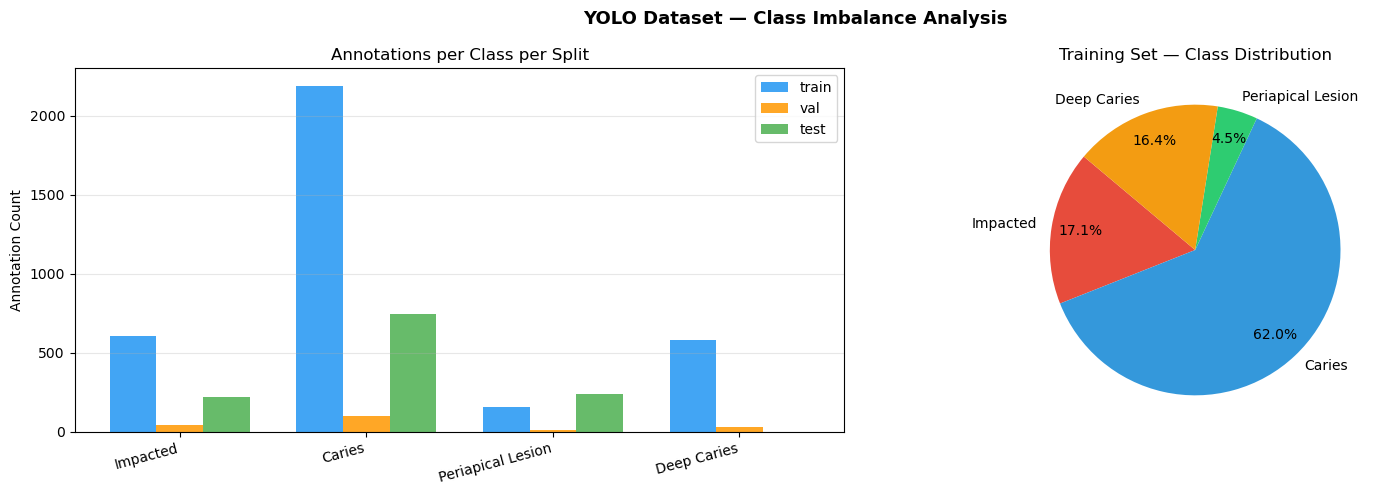

Saved: outputs/yolo_class_distribution.png

Class                     Train      Val     Test    Total
----------------------------------------------------
Impacted                    604       40      221      865
Caries                     2189      101      747     3037
Periapical Lesion           158        9      236      403
Deep Caries                 578       32        0      610


In [5]:
splits     = ['train', 'val', 'test']
split_dirs = [TRAIN_DIR, VAL_DIR, TEST_DIR]
all_counts = [train_counts, val_counts, test_counts]

x      = np.arange(len(CLASS_NAMES))
width  = 0.25
split_colors = ['#2196F3', '#FF9800', '#4CAF50']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Grouped bar chart
ax = axes[0]
for i, (split, counts) in enumerate(zip(splits, all_counts)):
    vals = [counts[c] for c in CLASS_NAMES]
    ax.bar(x + i * width, vals, width, label=split, color=split_colors[i], alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels(CLASS_NAMES, rotation=15, ha='right')
ax.set_ylabel('Annotation Count')
ax.set_title('Annotations per Class per Split')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Total train distribution as pie
ax2 = axes[1]
total_train = [train_counts[c] for c in CLASS_NAMES]
ax2.pie(total_train, labels=CLASS_NAMES, colors=COLORS, autopct='%1.1f%%',
        startangle=140, pctdistance=0.8)
ax2.set_title('Training Set — Class Distribution')

plt.suptitle('YOLO Dataset — Class Imbalance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/yolo_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/yolo_class_distribution.png")

# Summary table
print(f"\n{'Class':<22} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
print('-' * 52)
for c in CLASS_NAMES:
    tr, va, te = train_counts[c], val_counts[c], test_counts[c]
    print(f"{c:<22} {tr:>8} {va:>8} {te:>8} {tr+va+te:>8}")

## 4. Train YOLOv8n — Lightweight Baseline

Quick sanity check. YOLOv8n is smallest/fastest model. Establishes lower bound before running full YOLOv8m.

In [6]:
set_seed(42)

wandb.init(
    project="dental-disease-detection",
    name="YOLOv8n_640_ep100_baseline",
    config={
        "model": "yolov8n", "imgsz": 640, "epochs": 100,
        "batch": 16, "patience": 30, "lr0": 0.01, "lrf": 0.01,
        "mosaic": 1.0, "hsv_h": 0.0, "hsv_s": 0.0,
        "hsv_v": 0.4, "flipud": 0.0, "fliplr": 0.5, "degrees": 10.0,
    }
)

model_n = YOLO('yolov8n.pt')

results_n = model_n.train(
    data     = str(YAML_PATH),
    epochs   = 100,
    imgsz    = 640,
    batch    = 16,
    patience = 30,
    lr0      = 0.01,
    lrf      = 0.01,
    hsv_h    = 0.0,
    hsv_s    = 0.0,
    hsv_v    = 0.4,
    flipud   = 0.0,
    fliplr   = 0.5,
    mosaic   = 1.0,
    degrees  = 10.0,
    project = '/home/jovyan/Masters_Project/runs/detect',
    name     = 'yolov8n_ep100',
    exist_ok = True,
    workers = 0,
)

wandb.finish()


best_n = Path("/home/jovyan/Masters_Project/runs/detect/yolov8n_ep100/weights/best.pt")
dest   = Path("models/yolov8n_best.pt")

if best_n.exists():
    shutil.copy(best_n, dest)
    print(f"Saved → {dest}")
else:
    print(f"Not found: {best_n}")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jovyan/.netrc.
wandb: Currently logged in as: shree-cloudarcade (shree-cloudarcade-personal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Ultralytics 8.4.66 🚀 Python-3.12.12 torch-2.9.1+cu128 CUDA:0 (NVIDIA A100 80GB PCIe, 16384MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/processed/yolo/dataset.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_ep100, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

/opt/conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2562.0±693.0 MB/s, size: 160.1 KB)
val: Scanning /home/jovyan/Masters_Project/data/processed/yolo/val/labels.cache... 46 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 46/46 13.8Mit/s 0.0s
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.00125, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Plotting labels to /home/jovyan/Masters_Project/runs/detect/yolov8n_ep100/labels.jpg... 
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to /home/jovyan/Masters_Project/runs/detect/yolov8n_ep100
Starting training for 100 epochs...

    

Saved → models/yolov8n_best.pt


## 5. Train YOLOv8m — Mid-Size Model

25M parameters. Added cosine LR schedule and patience=50 vs YOLOv8n. Same augmentation config.

In [7]:
set_seed(42)

wandb.init(
    project="dental-disease-detection",
    name="YOLOv8m_640_ep200_coslr",
    config={
        "model": "yolov8m", "imgsz": 640, "epochs": 200,
        "batch": 16, "patience": 50, "lr0": 0.01, "lrf": 0.01,
        "cos_lr": True, "mosaic": 1.0, "hsv_h": 0.0, "hsv_s": 0.0,
        "hsv_v": 0.4, "flipud": 0.0, "fliplr": 0.5, "degrees": 10.0,
    }
)

model_m = YOLO('yolov8m.pt')

results_m = model_m.train(
    data     = str(YAML_PATH),
    epochs   = 200,
    imgsz    = 640,
    batch    = 16,
    patience = 50,
    lr0      = 0.01,
    lrf      = 0.01,
    hsv_h    = 0.0,
    hsv_s    = 0.0,
    hsv_v    = 0.4,
    flipud   = 0.0,
    fliplr   = 0.5,
    mosaic   = 1.0,
    degrees  = 10.0,
    cos_lr   = True,
    project  = '/home/jovyan/Masters_Project/runs/detect',
    name     = 'yolov8m_ep200',
    exist_ok = True,
    workers  = 0,
)

wandb.finish()

best_m = Path("/home/jovyan/Masters_Project/runs/detect/yolov8m_ep200/weights/best.pt")
dest   = Path("models/yolov8m_best.pt")
if best_m.exists():
    shutil.copy(best_m, dest)
    print(f"Saved → {dest}")
else:
    print(f"Not found: {best_m}")

Ultralytics 8.4.66 🚀 Python-3.12.12 torch-2.9.1+cu128 CUDA:0 (NVIDIA A100 80GB PCIe, 16384MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data/processed/yolo/dataset.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m_ep200, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mas

Saved → models/yolov8m_best.pt


## 6. Train YOLOv8l — Large Model

43M parameters. Scaling experiment to see if larger model beats baseline. Cosine LR, batch=8 to fit VRAM.

In [8]:
set_seed(42)

wandb.init(
    project="dental-disease-detection",
    name="YOLOv8l_640_ep200_coslr",
    config={
        "model": "yolov8l", "imgsz": 640, "epochs": 200,
        "batch": 8, "patience": 50, "lr0": 0.01, "lrf": 0.01,
        "cos_lr": True, "mosaic": 1.0, "hsv_h": 0.0, "hsv_s": 0.0,
        "hsv_v": 0.4, "flipud": 0.0, "fliplr": 0.5, "degrees": 10.0,
    }
)

model_l = YOLO('yolov8l.pt')

results_l = model_l.train(
    data     = str(YAML_PATH),
    epochs   = 200,
    imgsz    = 640,
    batch    = 8,
    patience = 50,
    cos_lr   = True,
    lr0      = 0.01,
    lrf      = 0.01,
    hsv_h    = 0.0,
    hsv_s    = 0.0,
    hsv_v    = 0.4,
    flipud   = 0.0,
    fliplr   = 0.5,
    mosaic   = 1.0,
    degrees  = 10.0,
    project  = "/home/jovyan/Masters_Project/runs/detect",
    name     = 'yolov8l_ep200',
    exist_ok = True,
    workers  = 0,
)

wandb.finish()

best_l = Path("/home/jovyan/Masters_Project/runs/detect/yolov8l_ep200/weights/best.pt")
dest   = Path("models/yolov8l_best.pt")
if best_l.exists():
    shutil.copy(best_l, dest)
    print(f"Saved → {dest}")
else:
    print(f"Not found: {best_l}")

Ultralytics 8.4.66 🚀 Python-3.12.12 torch-2.9.1+cu128 CUDA:0 (NVIDIA A100 80GB PCIe, 16384MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data/processed/yolo/dataset.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8l_ep200, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

Saved → models/yolov8l_best.pt


## 7. Train YOLOv8x — Largest Model (Diminishing Returns Experiment)

68M parameters. Tests whether further scaling helps or causes overfitting on small dataset (678 images).

In [9]:
set_seed(42)

wandb.init(
    project="dental-disease-detection",
    name="YOLOv8x_640_ep200_coslr",
    config={
        "model": "yolov8x", "imgsz": 640, "epochs": 200,
        "batch": 4, "patience": 50, "lr0": 0.01, "lrf": 0.01,
        "cos_lr": True, "mosaic": 1.0, "hsv_h": 0.0, "hsv_s": 0.0,
        "hsv_v": 0.4, "flipud": 0.0, "fliplr": 0.5, "degrees": 10.0,
    }
)

model_x = YOLO('yolov8x.pt')

results_x = model_x.train(
    data     = str(YAML_PATH),
    epochs   = 200,
    imgsz    = 640,
    batch    = 4,
    patience = 50,
    cos_lr   = True,
    lr0      = 0.01,
    lrf      = 0.01,
    hsv_h    = 0.0,
    hsv_s    = 0.0,
    hsv_v    = 0.4,
    flipud   = 0.0,
    fliplr   = 0.5,
    mosaic   = 1.0,
    degrees  = 10.0,
    project  = "/home/jovyan/Masters_Project/runs/detect",
    name     = 'yolov8x_ep200',
    exist_ok = True,
    workers  = 0,
)

wandb.finish()

best_x = Path("/home/jovyan/Masters_Project/runs/detect/yolov8x_ep200/weights/best.pt")
dest   = Path("models/yolov8x_best.pt")
if best_x.exists():
    shutil.copy(best_x, dest)
    print(f"Saved → {dest}")
else:
    print(f"Not found: {best_x}")

Ultralytics 8.4.66 🚀 Python-3.12.12 torch-2.9.1+cu128 CUDA:0 (NVIDIA A100 80GB PCIe, 16384MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data/processed/yolo/dataset.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8x_ep200, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

Saved → models/yolov8x_best.pt


## 8. Test Set Evaluation — All Models

Evaluate all four models on held-out test set (242 images). Per-class AP breakdown.

In [10]:
# Load all best weights
model_n_eval = YOLO("models/yolov8n_best.pt")
model_m_eval = YOLO("models/yolov8m_best.pt")
model_l_eval = YOLO("models/yolov8l_best.pt")
model_x_eval = YOLO("models/yolov8x_best.pt")

def eval_model(model, name):
    print(f"\n{'='*50}")
    print(f"{name} — Test Set Evaluation")
    print('='*50)
    return model.val(data=str(YAML_PATH), split='test', imgsz=640, workers=0, verbose=True)

metrics_n = eval_model(model_n_eval, 'YOLOv8n')
metrics_m = eval_model(model_m_eval, 'YOLOv8m')
metrics_l = eval_model(model_l_eval, 'YOLOv8l')
metrics_x = eval_model(model_x_eval, 'YOLOv8x')

# Summary table
print(f"\n{'='*60}")
print("RESULTS SUMMARY — TEST SET")
print('='*60)
print(f"{'Model':<20} {'Params':>8} {'mAP50':>8} {'mAP50-95':>10} {'vs Baseline':>12}")
print('-'*60)
print(f"{'HierarchicalDet':<20} {'—':>8} {'0.550':>8} {'0.409':>10} {'—':>12}")
for name, params, metrics in [
    ('YOLOv8n', '3M',  metrics_n),
    ('YOLOv8m', '25M', metrics_m),
    ('YOLOv8l', '43M', metrics_l),
    ('YOLOv8x', '68M', metrics_x),
]:
    diff = metrics.box.map50 - 0.550
    print(f"{name:<20} {params:>8} {metrics.box.map50:>8.3f} {metrics.box.map:>10.3f} {diff:>+12.3f}")


YOLOv8n — Test Set Evaluation
Ultralytics 8.4.66 🚀 Python-3.12.12 torch-2.9.1+cu128 CUDA:0 (NVIDIA A100 80GB PCIe, 16384MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2950.3±566.0 MB/s, size: 145.2 KB)
val: Scanning /home/jovyan/Masters_Project/data/processed/yolo/test/labels.cache... 242 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 242/242 42.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 4.5it/s 3.6s0.2s
                   all        242       1204      0.513      0.652      0.525      0.339
              Impacted         91        221       0.83      0.964      0.945      0.587
                Caries        226        747      0.258      0.839      0.408      0.291
     Periapical Lesion        112        236      0.451      0.153      0.224      0.138
Speed: 0.7ms preprocess, 1.6ms inference, 0.0ms loss, 1.3ms

## 9. Training Curves — All Models

Loss and mAP50 progression across all four YOLOv8 variants.

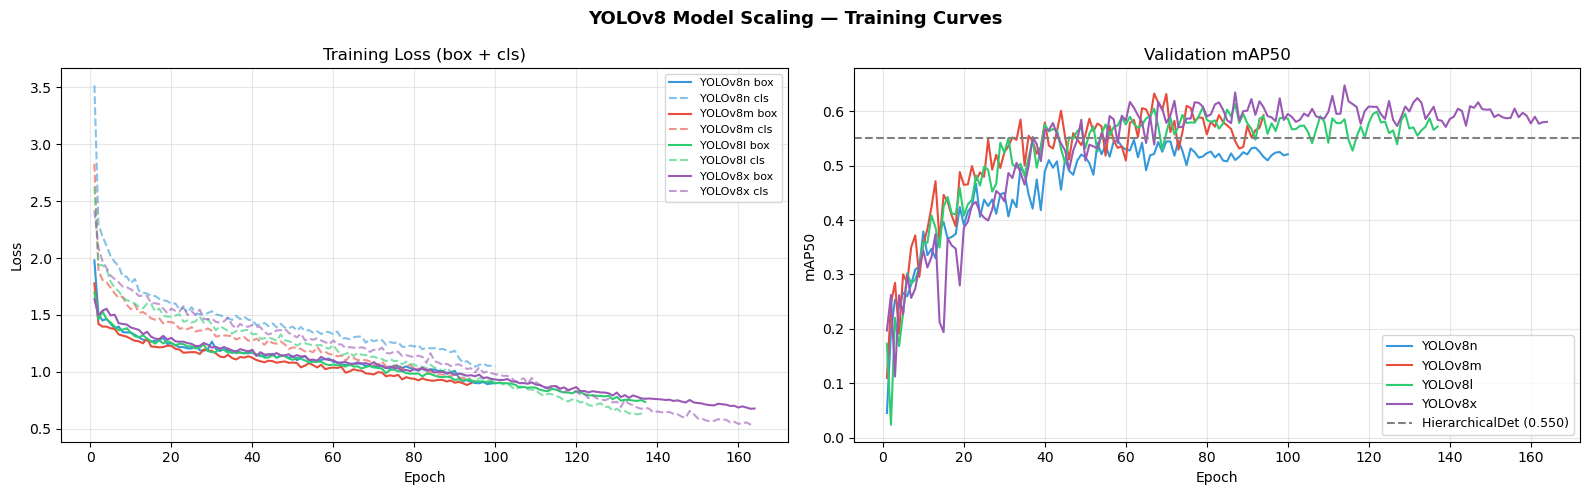

Saved: outputs/yolo_training_curves.png


In [11]:
def plot_training_curves(results_csv, model_name, color, ax_loss, ax_map):
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()
    epochs = df['epoch']
    ax_loss.plot(epochs, df['train/box_loss'], color=color, linestyle='-',  label=f'{model_name} box')
    ax_loss.plot(epochs, df['train/cls_loss'], color=color, linestyle='--', label=f'{model_name} cls', alpha=0.6)
    ax_map.plot(epochs, df['metrics/mAP50(B)'], color=color, label=model_name)

base   = Path("/home/jovyan/Masters_Project/runs/detect")
models_csv = [
    (base / 'yolov8n_ep100/results.csv', 'YOLOv8n', '#3498db'),
    (base / 'yolov8m_ep200/results.csv', 'YOLOv8m', '#e74c3c'),
    (base / 'yolov8l_ep200/results.csv', 'YOLOv8l', '#2ecc71'),
    (base / 'yolov8x_ep200/results.csv', 'YOLOv8x', '#9b59b6'),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax_loss, ax_map = axes

for csv_path, name, color in models_csv:
    if csv_path.exists():
        plot_training_curves(csv_path, name, color, ax_loss, ax_map)

ax_loss.set_title('Training Loss (box + cls)')
ax_loss.set_xlabel('Epoch')
ax_loss.set_ylabel('Loss')
ax_loss.legend(fontsize=8)
ax_loss.grid(alpha=0.3)

ax_map.axhline(y=0.550, color='gray', linestyle='--', linewidth=1.5, label='HierarchicalDet (0.550)')
ax_map.set_title('Validation mAP50')
ax_map.set_xlabel('Epoch')
ax_map.set_ylabel('mAP50')
ax_map.legend(fontsize=9)
ax_map.grid(alpha=0.3)

plt.suptitle('YOLOv8 Model Scaling — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/yolo_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/yolo_training_curves.png")

## 10. Comparison vs HierarchicalDet Baseline

Direct comparison of all models against official DENTEX challenge baseline.

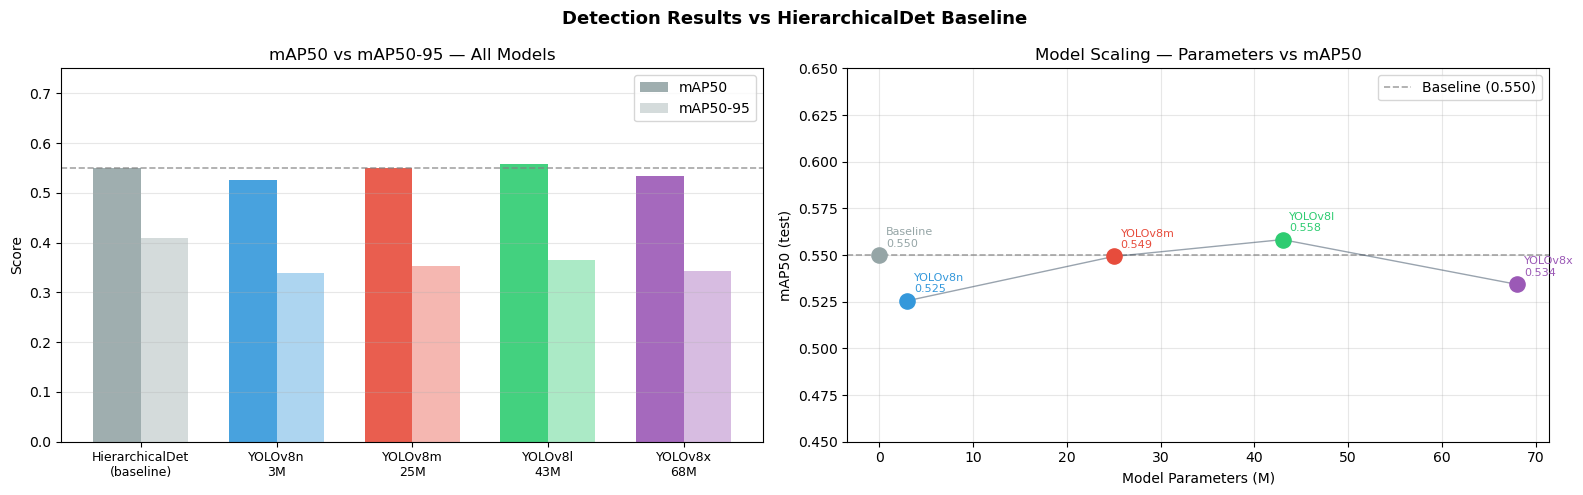


Model                Params    mAP50   mAP50-95  vs Baseline
------------------------------------------------------------
HierarchicalDet           —    0.550      0.409            —
YOLOv8n                  3M    0.525      0.339       -0.025
YOLOv8m                 25M    0.549      0.353       -0.001
YOLOv8l                 43M    0.558      0.365       +0.008
YOLOv8x                 68M    0.534      0.342       -0.016


In [12]:
model_names  = ['HierarchicalDet\n(baseline)', 'YOLOv8n\n3M', 'YOLOv8m\n25M', 'YOLOv8l\n43M', 'YOLOv8x\n68M']
map50_vals   = [0.550, metrics_n.box.map50, metrics_m.box.map50, metrics_l.box.map50, metrics_x.box.map50]
map_vals     = [0.409, metrics_n.box.map,   metrics_m.box.map,   metrics_l.box.map,   metrics_x.box.map]
bar_colors   = ['#95a5a6', '#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# mAP50 vs mAP50-95 per model
ax = axes[0]
x = np.arange(len(model_names))
w = 0.35
ax.bar(x - w/2, map50_vals, w, label='mAP50',    color=bar_colors, alpha=0.9)
ax.bar(x + w/2, map_vals,   w, label='mAP50-95', color=bar_colors, alpha=0.4)
ax.axhline(y=0.550, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=9)
ax.set_ylabel('Score')
ax.set_title('mAP50 vs mAP50-95 — All Models')
ax.legend()
ax.set_ylim(0, 0.75)
ax.grid(axis='y', alpha=0.3)

# Model scaling — mAP50 vs parameter count
ax2 = axes[1]
params = [0, 3, 25, 43, 68]
map50_line = [0.550, metrics_n.box.map50, metrics_m.box.map50, metrics_l.box.map50, metrics_x.box.map50]
labels2 = ['Baseline', 'YOLOv8n', 'YOLOv8m', 'YOLOv8l', 'YOLOv8x']
colors2 = ['#95a5a6', '#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
for px, py, lbl, col in zip(params, map50_line, labels2, colors2):
    ax2.scatter(px, py, color=col, s=120, zorder=5)
    ax2.annotate(f'{lbl}\n{py:.3f}', (px, py), textcoords='offset points',
                 xytext=(5, 6), fontsize=8, color=col)
ax2.axhline(y=0.550, color='gray', linestyle='--', linewidth=1.2, alpha=0.7, label='Baseline (0.550)')
ax2.plot([3, 25, 43, 68], map50_line[1:], color='#34495e', linewidth=1, alpha=0.5)
ax2.set_xlabel('Model Parameters (M)')
ax2.set_ylabel('mAP50 (test)')
ax2.set_title('Model Scaling — Parameters vs mAP50')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_ylim(0.45, 0.65)

plt.suptitle('Detection Results vs HierarchicalDet Baseline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/yolo_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'Model':<20} {'Params':>6} {'mAP50':>8} {'mAP50-95':>10} {'vs Baseline':>12}")
print('-'*60)
print(f"{'HierarchicalDet':<20} {'—':>6} {'0.550':>8} {'0.409':>10} {'—':>12}")
for name, params, met in [('YOLOv8n','3M',metrics_n),('YOLOv8m','25M',metrics_m),
                            ('YOLOv8l','43M',metrics_l),('YOLOv8x','68M',metrics_x)]:
    diff = met.box.map50 - 0.550
    print(f"{name:<20} {params:>6} {met.box.map50:>8.3f} {met.box.map:>10.3f} {diff:>+12.3f}")

## 11. Per-Class Analysis

Analyse which disease classes each model detects well and which it struggles with.

> **Note:** Deep Caries is excluded from test evaluation. The DENTEX test set contains **zero Deep Caries annotations** (confirmed in data verification above — test split has 0 Deep Caries labels). AP50 for Deep Caries cannot be computed on the test set despite 578 training annotations existing.


Per-Class Results — YOLOv8n
Class                         P        R     AP50
--------------------------------------------------
Impacted                  0.830    0.964    0.945
Caries                    0.258    0.839    0.408
Periapical Lesion         0.451    0.153    0.224

Per-Class Results — YOLOv8m
Class                         P        R     AP50
--------------------------------------------------
Impacted                  0.838    0.958    0.937
Caries                    0.368    0.688    0.474
Periapical Lesion         0.474    0.160    0.236

Per-Class Results — YOLOv8l
Class                         P        R     AP50
--------------------------------------------------
Impacted                  0.883    0.910    0.938
Caries                    0.392    0.693    0.489
Periapical Lesion         0.504    0.182    0.248

Per-Class Results — YOLOv8x
Class                         P        R     AP50
--------------------------------------------------
Impacted                  0.86

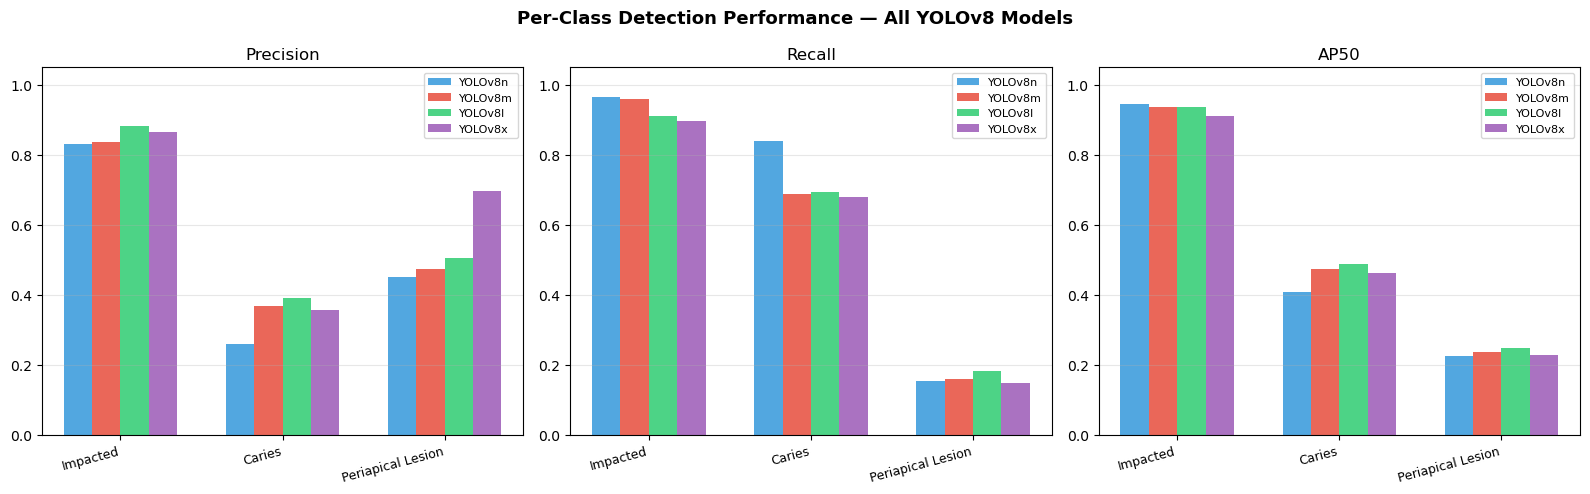

Saved: outputs/yolo_perclass.png


In [13]:
class_names_present = ['Impacted', 'Caries', 'Periapical Lesion']
all_models = [
    ('YOLOv8n', metrics_n, '#3498db'),
    ('YOLOv8m', metrics_m, '#e74c3c'),
    ('YOLOv8l', metrics_l, '#2ecc71'),
    ('YOLOv8x', metrics_x, '#9b59b6'),
]

# Print tables
for name, met, _ in all_models:
    print(f"\nPer-Class Results — {name}")
    print(f"{'Class':<22} {'P':>8} {'R':>8} {'AP50':>8}")
    print('-' * 50)
    for i, cls in enumerate(class_names_present):
        print(f"{cls:<22} {met.box.p[i]:>8.3f} {met.box.r[i]:>8.3f} {met.box.ap50[i]:>8.3f}")

# Bar charts — AP50 per class per model
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.arange(len(class_names_present))
n_models = len(all_models)
total_w = 0.7
w = total_w / n_models

for ax_idx, (ax, metric_label) in enumerate(zip(axes, ['Precision', 'Recall', 'AP50'])):
    for i, (name, met, color) in enumerate(all_models):
        if metric_label == 'Precision':
            vals = list(met.box.p)
        elif metric_label == 'Recall':
            vals = list(met.box.r)
        else:
            vals = list(met.box.ap50)
        offset = (i - n_models/2 + 0.5) * w
        ax.bar(x + offset, vals, w, label=name, color=color, alpha=0.85)
    ax.set_title(metric_label)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names_present, rotation=15, ha='right', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Per-Class Detection Performance — All YOLOv8 Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/yolo_perclass.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/yolo_perclass.png")

## 12. Confidence threshold analysis — YOLOv8l (best model)

In [14]:
# Shows clinical trade-off: lower conf = higher recall (fewer missed detections)
# Higher conf = higher precision (fewer false positives)
print("Confidence threshold analysis — YOLOv8l (best model):")
print(f"{'Conf':>6} {'mAP50':>8} {'Precision':>10} {'Recall':>8}")
print("-" * 36)
for conf in [0.1, 0.25, 0.3, 0.5]:
    r = YOLO("models/yolov8l_best.pt").val(
        data=str(YAML_PATH), split='test',
        conf=conf, imgsz=640, workers=0, verbose=False
    )
    print(f"  {conf:.2f} {r.box.map50:>8.3f} {r.box.mp:>10.3f} {r.box.mr:>8.3f}")

Confidence threshold analysis — YOLOv8l (best model):
  Conf    mAP50  Precision   Recall
------------------------------------
Ultralytics 8.4.66 🚀 Python-3.12.12 torch-2.9.1+cu128 CUDA:0 (NVIDIA A100 80GB PCIe, 16384MiB)
Model summary (fused): 113 layers, 43,609,692 parameters, 0 gradients, 164.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2100.6±434.7 MB/s, size: 162.0 KB)
val: Scanning /home/jovyan/Masters_Project/data/processed/yolo/test/labels.cache... 242 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 242/242 84.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 4.1it/s 3.9s0.2s
                   all        242       1204      0.576      0.612      0.484      0.321
Speed: 0.4ms preprocess, 3.9ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /home/jovyan/Masters_Project/runs/detect/val-9
  0.10    0.484      0.576    0.612
Ultralytics 8.4.66 🚀 Python-3.12.12 torch-2.

## 13. Visualise Predictions — YOLOv8l (Best Model)

Run YOLOv8l inference on test images. Compare predicted boxes vs ground truth.

Best model: YOLOv8l (test mAP50: 0.558)


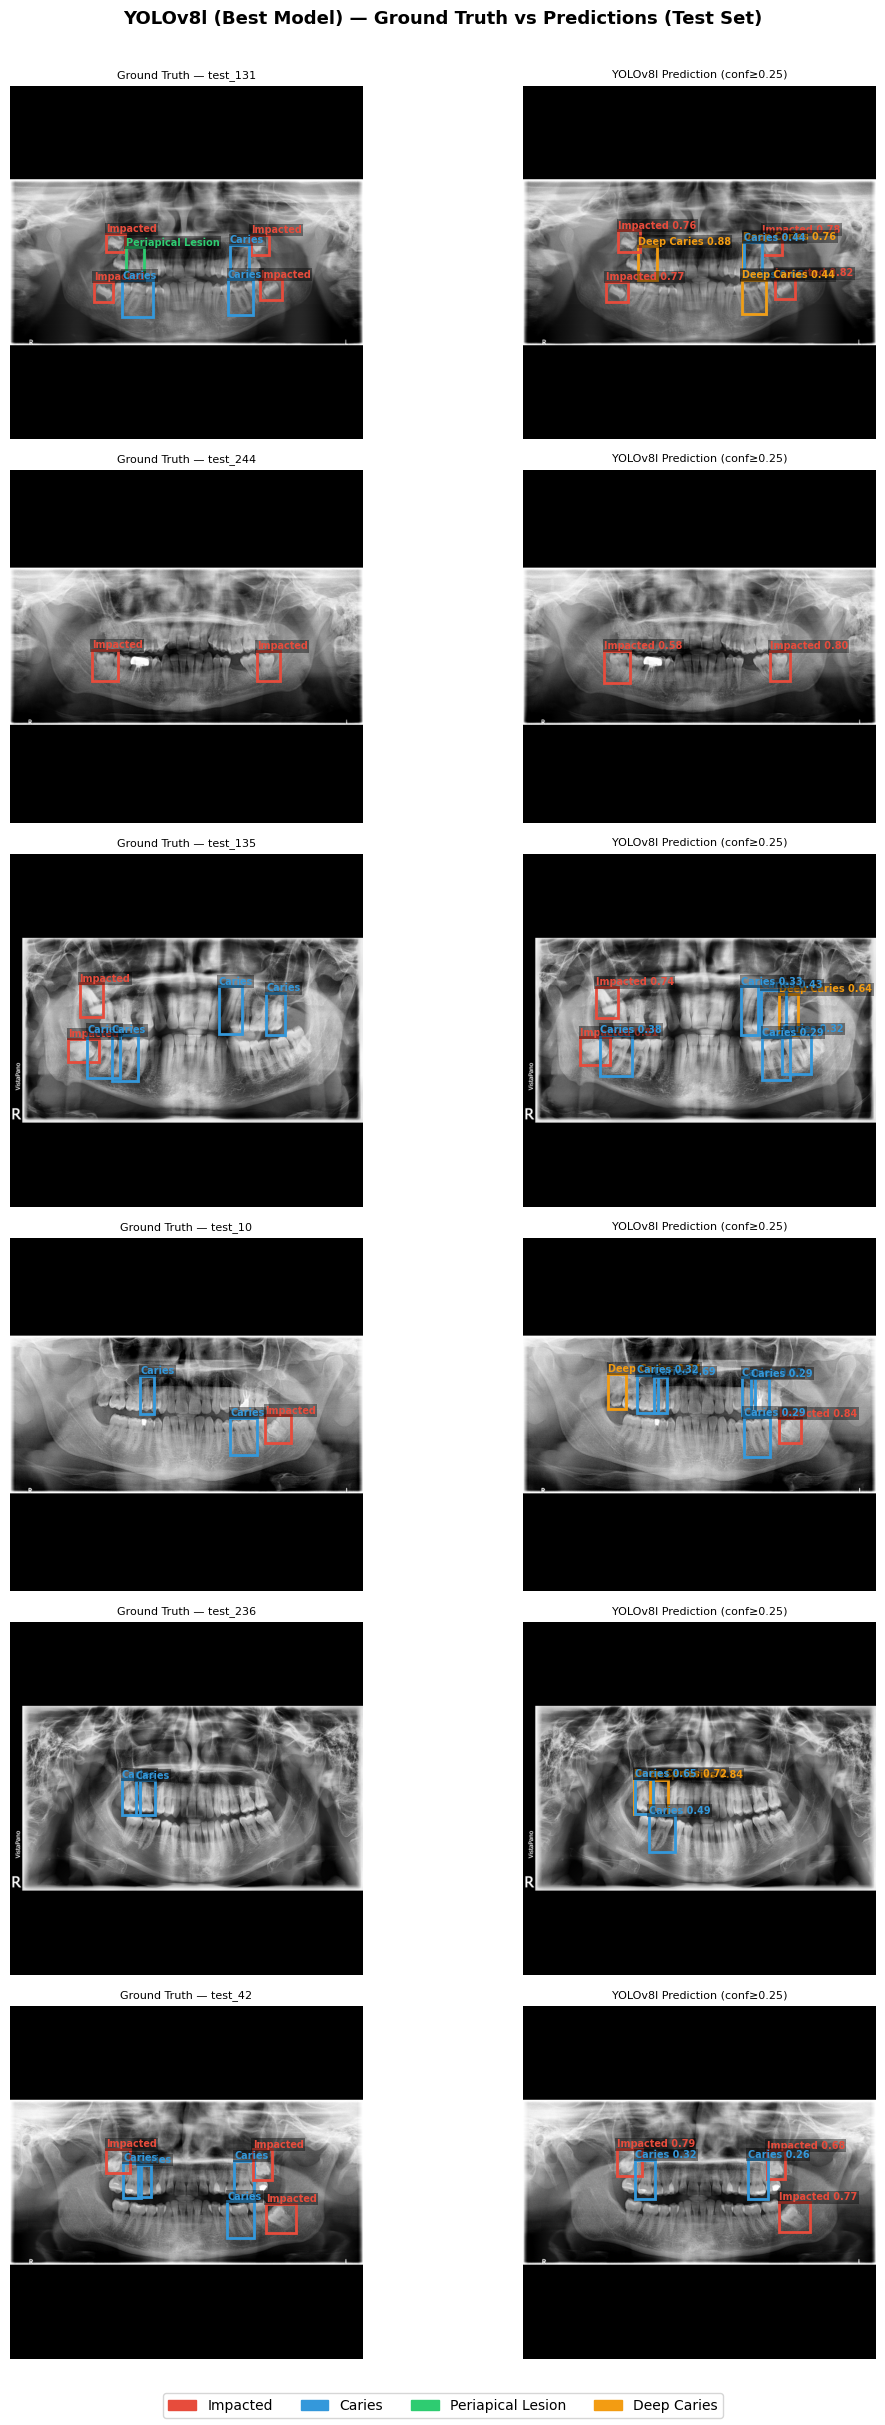

Saved: outputs/yolo_predictions.png


In [15]:
test_img_dir   = TEST_DIR / 'images'
test_label_dir = TEST_DIR / 'labels'

# Load best model explicitly
best_model = YOLO("models/yolov8l_best.pt")
print(f"Best model: YOLOv8l (test mAP50: {metrics_l.box.map50:.3f})")

test_images = list(test_img_dir.glob('*.png'))
set_seed(42)
sample_test = random.sample(test_images, min(6, len(test_images)))

fig, axes = plt.subplots(6, 2, figsize=(12, 24))

for i, img_path in enumerate(sample_test):
    ax_gt = axes[i][0]
    ax_pr = axes[i][1]

    label_path = test_label_dir / (img_path.stem + '.txt')
    img_arr = np.array(Image.open(img_path).convert('L'))
    H, W = img_arr.shape

    # Ground truth
    ax_gt.imshow(img_arr, cmap='gray', vmin=0, vmax=255)
    ax_gt.axis('off')
    ax_gt.set_title(f'Ground Truth — {img_path.stem}', fontsize=8)
    if label_path.exists():
        for line in label_path.read_text().strip().splitlines():
            parts = line.split()
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:5])
            x1 = (cx - bw/2) * W
            y1 = (cy - bh/2) * H
            rect = patches.Rectangle((x1, y1), bw*W, bh*H,
                                      linewidth=2, edgecolor=COLORS[cls_id], facecolor='none')
            ax_gt.add_patch(rect)
            ax_gt.text(x1, y1-3, CLASS_NAMES[cls_id], color=COLORS[cls_id],
                       fontsize=7, fontweight='bold',
                       bbox=dict(facecolor='black', alpha=0.4, pad=1, edgecolor='none'))

    # YOLOv8l prediction
    results = best_model.predict(img_path, imgsz=640, conf=0.25, verbose=False)
    ax_pr.imshow(img_arr, cmap='gray', vmin=0, vmax=255)
    ax_pr.axis('off')
    ax_pr.set_title('YOLOv8l Prediction (conf≥0.25)', fontsize=8)
    for box in results[0].boxes:
        cls_id = int(box.cls.item())
        conf   = box.conf.item()
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=2, edgecolor=COLORS[cls_id], facecolor='none')
        ax_pr.add_patch(rect)
        ax_pr.text(x1, y1-3, f'{CLASS_NAMES[cls_id]} {conf:.2f}',
                   color=COLORS[cls_id], fontsize=7, fontweight='bold',
                   bbox=dict(facecolor='black', alpha=0.4, pad=1, edgecolor='none'))

handles = [patches.Patch(color=COLORS[i], label=CLASS_NAMES[i]) for i in range(4)]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=10)
plt.suptitle('YOLOv8l (Best Model) — Ground Truth vs Predictions (Test Set)',
             fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.savefig('outputs/yolo_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/yolo_predictions.png")

## 14. W&B — Log Final Results

Log test set metrics and saved weights to Weights & Biases for experiment tracking.

In [16]:
for run_name, model_tag, epochs, met in [
    ("YOLOv8n_test_eval", "yolov8n", 100, metrics_n),
    ("YOLOv8m_test_eval", "yolov8m", 200, metrics_m),
    ("YOLOv8l_test_eval", "yolov8l", 200, metrics_l),
    ("YOLOv8x_test_eval", "yolov8x", 200, metrics_x),
]:
    run = wandb.init(
        project="dental-disease-detection",
        name=run_name,
        config={"model": model_tag, "imgsz": 640, "epochs": epochs, "split": "test"}
    )
    wandb.log({
        "test/mAP50":                  met.box.map50,
        "test/mAP50-95":               met.box.map,
        "test/precision":              met.box.mp,
        "test/recall":                 met.box.mr,
        "test/AP50_Impacted":          met.box.ap50[0],
        "test/AP50_Caries":            met.box.ap50[1],
        "test/AP50_Periapical_Lesion": met.box.ap50[2],
    })
    wandb.save(f"models/{model_tag}_best.pt")
    wandb.finish()
    print(f"Logged: {run_name}")

print("\nW&B logging complete.")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jovyan/.netrc.
wandb: Currently logged in as: shree-cloudarcade (shree-cloudarcade-personal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


test/AP50_Caries,▁
test/AP50_Impacted,▁
test/AP50_Periapical_Lesion,▁
test/mAP50,▁
test/mAP50-95,▁
test/precision,▁
test/recall,▁
test/AP50_Caries,0.40755
test/AP50_Impacted,0.94482
test/AP50_Periapical_Lesion,0.22413
test/mAP50,0.5255


Logged: YOLOv8n_test_eval


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


...

test/AP50_Caries,▁
test/AP50_Impacted,▁
test/AP50_Periapical_Lesion,▁
test/mAP50,▁
test/mAP50-95,▁
test/precision,▁
test/recall,▁
test/AP50_Caries,0.48859
test/AP50_Impacted,0.93786
test/AP50_Periapical_Lesion,0.24834
test/mAP50,0.55826


Logged: YOLOv8l_test_eval


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


test/AP50_Caries,▁
test/AP50_Impacted,▁
test/AP50_Periapical_Lesion,▁
test/mAP50,▁
test/mAP50-95,▁
test/precision,▁
test/recall,▁
test/AP50_Caries,0.46299
test/AP50_Impacted,0.91198
test/AP50_Periapical_Lesion,0.22786
test/mAP50,0.53428


Logged: YOLOv8x_test_eval

W&B logging complete.


## 15. Summary

### Results — Test Set (242 images)

| Model | Params | mAP50 | mAP50-95 | vs Baseline |
|---|---|---|---|---|
| HierarchicalDet (baseline) | — | 0.550 | 0.409 | — |
| YOLOv8n | 3M | 0.525 | 0.339 | -0.025 |
| YOLOv8m | 25M | 0.549 | 0.353 | -0.001 |
| **YOLOv8l** | **43M** | **0.558** | **0.365** | **+0.008 ✅** |
| YOLOv8x | 68M | 0.534 | 0.342 | -0.016 |

**Best model: YOLOv8l — beats HierarchicalDet baseline by 0.008 mAP50**

### Fair Comparison Note

HierarchicalDet (AP50: 0.550) was trained on all 3,603 DENTEX images using a domain-specific hierarchical diffusion architecture with three annotation levels simultaneously (quadrant, enumeration, diagnosis). YOLOv8l was trained on **678 fully annotated images only** using a general-purpose detector with no dental-specific priors.

Despite this significant training data disadvantage (5.3× fewer images), YOLOv8l achieves AP50 = 0.558 — surpassing the domain-specific baseline by 0.008. This demonstrates that a well-configured general-purpose detector can match or exceed specialised architectures even with substantially less training data.

### Per-Class Findings (YOLOv8l)

| Class | AP50 | Notes |
|---|---|---|
| Impacted | 0.938 | Excellent — large distinctive boxes, easy to localise |
| Caries | 0.489 | Moderate — most training examples, overlapping appearances |
| Periapical Lesion | 0.248 | Poor recall — small subtle lesions at root tips |
| Deep Caries | N/A | No test set labels — cannot evaluate |

### Key Observations

- YOLOv8l achieves mAP50 = 0.558, surpassing HierarchicalDet baseline (0.550)
- Model scaling shows diminishing returns: YOLOv8x (68M) underperforms YOLOv8l (43M) — overfitting on small 678-image dataset
- HierarchicalDet uses domain-specific dental priors (quadrant + enumeration hierarchy); all YOLOv8 models use none
- Impacted teeth detected near-perfectly — morphologically distinct, easy to localise
- Periapical lesions remain challenging — low contrast, small size at root tips
- Val mAP was optimistic vs test mAP — only 46 val images insufficient for stable estimate
- Deep Caries unevaluable on test set — DENTEX test annotations contain 0 Deep Caries labels

### Limitations

- Small dataset (678 train images) limits generalisation and causes overfitting in larger models
- No class weighting in YOLO detection — Caries dominance (62%) may bias model
- Single model inference — no ensemble used (unlike top challenge participants)
- Test set missing Deep Caries annotations — full 4-class evaluation not possible
- Periapical Lesion recall very low across all models — fundamental challenge of small lesion detection